<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Curso_python_Ciencia_de_Datos/blob/main/e)_Underfitting_and_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ajuste Insuficiente (infraajuste) y Sobreajuste** (Underfitting and Overfitting)

Ajusta tu modelo para un mejor rendimiento.

Al final de este paso, comprenderás los conceptos de ajuste insuficiente (underfitting) y sobreajuste (overfitting), y serás capaz de aplicar estas ideas para hacer tus modelos más precisos.

### **Experimentando con Diferentes Modelos**

Ahora que tienes una forma confiable de medir la precisión de un modelo, puedes experimentar con modelos alternativos y ver cuál ofrece las mejores predicciones. Pero, ¿qué alternativas tienes para los modelos?

Puedes ver en la [documentación de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) que el modelo de árbol de decisión tiene muchas opciones (más de las que necesitarás por mucho tiempo). Las opciones más importantes determinan la profundidad del árbol.  Recuerda de [la primera lección de este curso](https://colab.research.google.com/drive/1ILjR_ElfNDXplteWluTJIW6kqNNpfSEm?usp=drive_link) que la profundidad de un árbol es una medida de cuántas divisiones (splits) realiza antes de llegar a una predicción. Este es un árbol relativamente poco profundo.

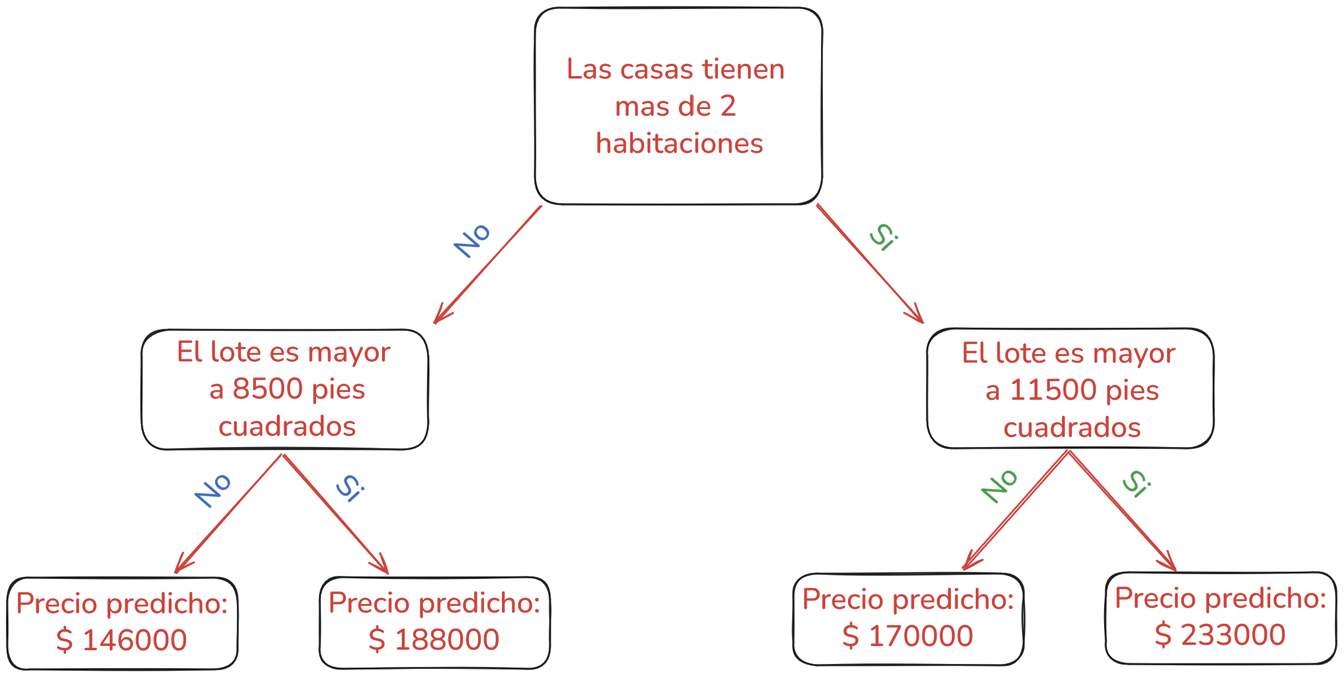

En la práctica, no es raro que un árbol tenga 10 divisiones entre el nivel superior (todas las casas) y una hoja. A medida que el árbol se hace más profundo, el conjunto de datos se divide en hojas con menos casas. Si un árbol solo tuviera 1 división, dividiría los datos en 2 grupos. Si cada grupo se divide de nuevo, obtendríamos 4 grupos de casas. Dividir cada uno de esos de nuevo crearía 8 grupos. Si seguimos duplicando el número de grupos agregando más divisiones en cada nivel, tendremos 210 grupos de casas cuando lleguemos al décimo nivel. Eso son 1024 hojas.

Cuando dividimos las casas entre muchas hojas, también tenemos menos casas en cada hoja. Las hojas con muy pocas casas harán predicciones que son bastante cercanas a los valores reales de esas casas, pero pueden hacer predicciones muy poco fiables para nuevos datos (porque cada predicción se basa en solo unas pocas casas).

Este es un fenómeno llamado sobreajuste `overfitting`, donde un modelo coincide con los datos de entrenamiento casi a la perfección, pero se desempeña mal en la validación y en otros datos nuevos. Por otro lado, si hacemos que nuestro árbol sea muy poco profundo, no divide las casas en grupos muy distintos.

En un extremo, si un árbol divide las casas en solo 2 o 4 grupos, cada grupo todavía tiene una gran variedad de casas. Las predicciones resultantes pueden estar muy lejos para la mayoría de las casas, incluso en los datos de entrenamiento (y también será malo en la validación por la misma razón). Cuando un modelo no logra capturar distinciones y patrones importantes en los datos, por lo que se desempeña mal incluso en los datos de entrenamiento, eso se llama infraajuste `underfitting`.

Dado que nos importa la precisión en los datos nuevos, que estimamos a partir de nuestros datos de validación, queremos encontrar el punto óptimo entre el infraajuste y el sobreajuste. Visualmente, queremos el punto más bajo de la curva de validación (roja) en la siguiente figura.
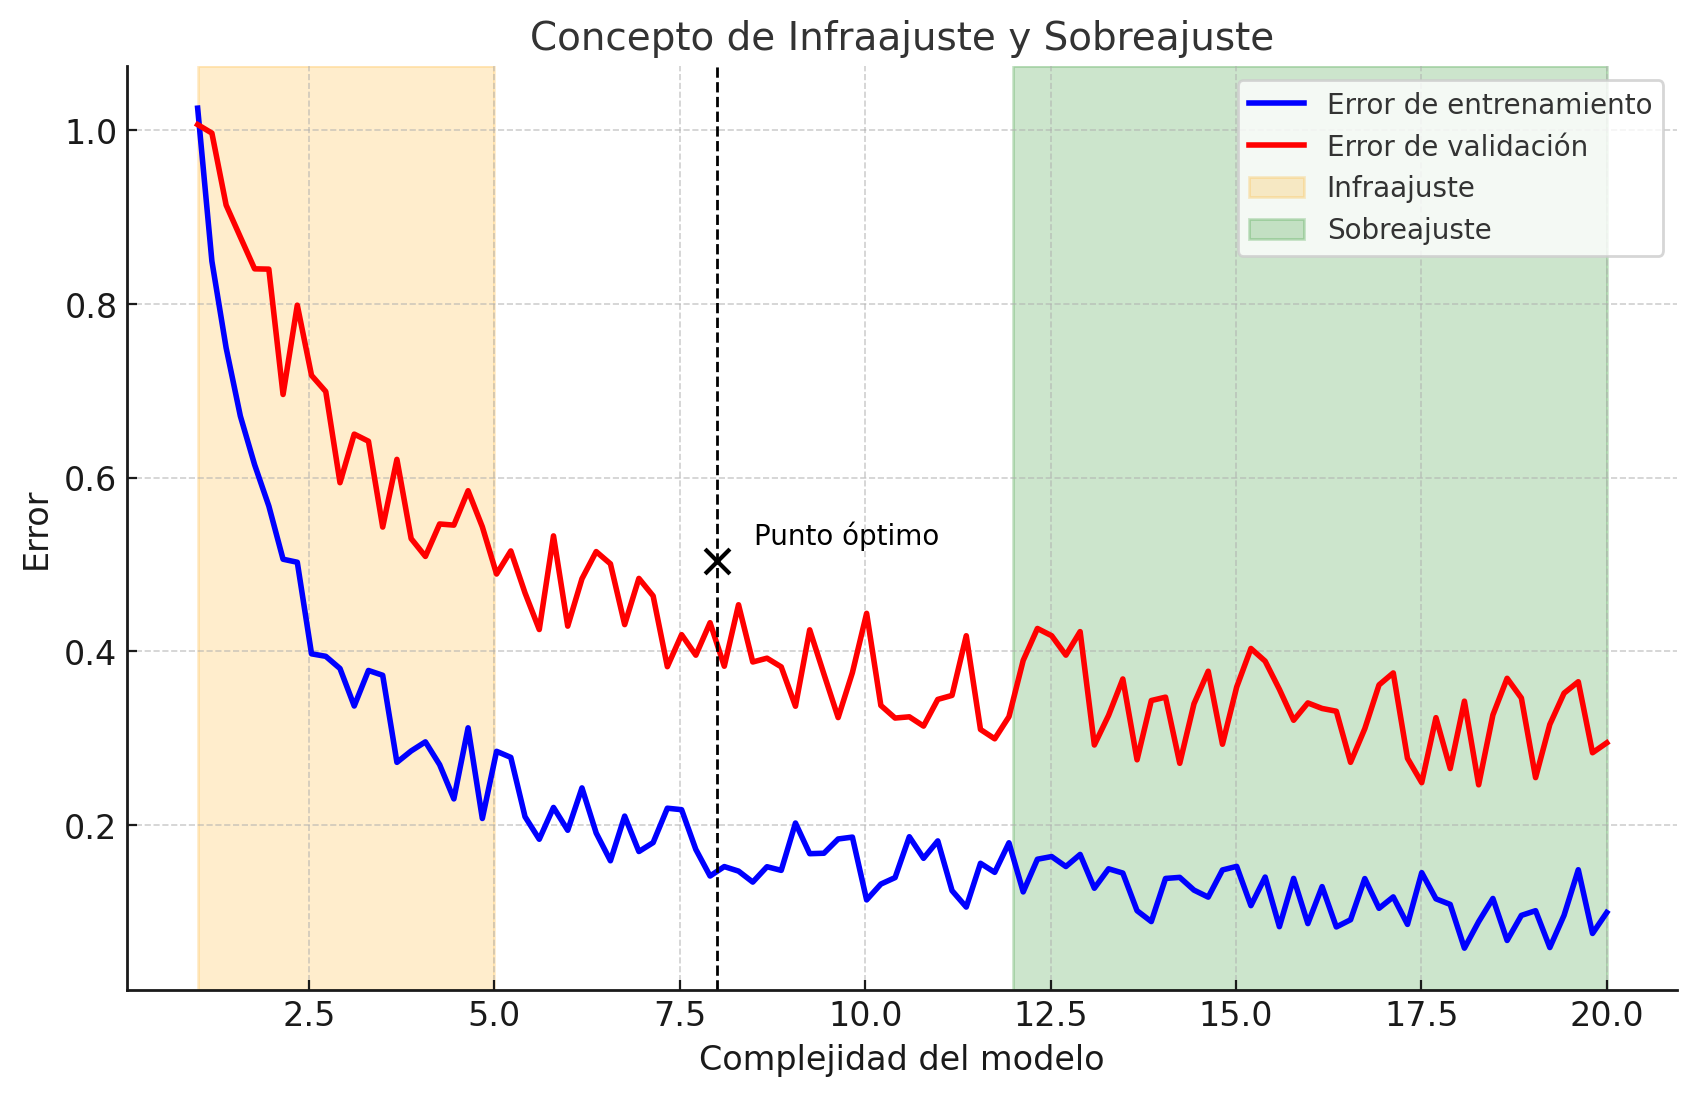

Hay algunas alternativas para controlar la profundidad del árbol, y muchas permiten que algunas rutas a través del árbol tengan mayor profundidad que otras. Sin embargo, el argumento `max_leaf_nodes` ofrece una forma muy sensata de controlar el sobreajuste frente al infraajuste. Cuantas más hojas permitamos que el modelo cree, más nos moveremos del área de infraajuste en el gráfico anterior al área de sobreajuste.

Podemos usar una función de utilidad para ayudarnos a comparar las puntuaciones `MAE` de diferentes valores para `max_leaf_nodes`.

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

# Load the data into a pandas DataFrame
melbourne_file_path = path + '/melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path)

# Print the first 5 rows of the DataFrame
display(melbourne_data.head(2))

In [ ]:
# Filtra las filas con valores faltantes
filtered_melbourne_data = melbourne_data.dropna(axis=0)

# Elige el objetivo (target) y las características (features)
y = filtered_melbourne_data.Price
melbourne_features = ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea',
                        'YearBuilt', 'Lattitude', 'Longtitude']
X = filtered_melbourne_data[melbourne_features]

from sklearn.model_selection import train_test_split

# Divide los datos en conjuntos de entrenamiento y validación, tanto para las características como para el objetivo
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

Podemos usar un bucle `for` para comparar la precisión de los modelos construidos con diferentes valores para `max_leaf_nodes`.

In [ ]:
for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))

**De las opciones listadas, 500 es el número óptimo de hojas.**

### **Conclusión**

En resumen, los modelos pueden sufrir de:

* Sobreajuste (**Overfitting**): Capturan patrones falsos que no se repetirán en el futuro, lo que lleva a predicciones menos precisas.

* Infraajuste (**Underfitting**): No logran capturar patrones relevantes, lo que también resulta en predicciones menos precisas.

Para medir la precisión de un modelo candidato, utilizamos datos de validación que no se usan en el entrenamiento del modelo. Esto nos permite probar muchos modelos candidatos y quedarnos con el mejor.